# Direct Detection - and Counting - YOLOv11

After the vehicles enter the intersection, we will check which direction they move toward. Based on this, we will calculate the total number of vehicles going in each direction, and therefore estimate the vehicle density for each direction.

In the image below, the **“up direction”** represents the lane in the upper-right corner, while the **“down direction”** represents the lane in the lower-left corner.

Identifying the direction in which vehicles move, in other words, the lane they use to exit the intersection, is important for traffic analysis. Therefore, these areas will form our ROI areas.

**The important part of this project is detecting whether a vehicle enters the selected green area. If it enters that area, we will count it.**

**Now, first we should move to the other notebook, the `ROI_selection` notebook, meaning the Region of Interest selection notebook, and examine and edit it.**


**Please go to the `ROI_selection` notebook, create the coordinates, and then return here.**


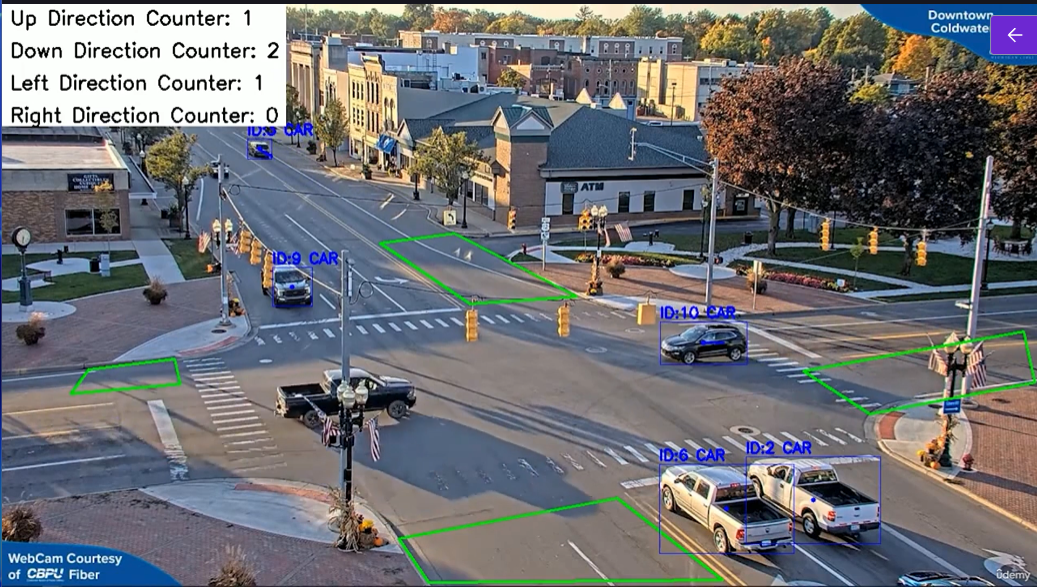

General Mind Map. The detailed version is located in the notebook folder.

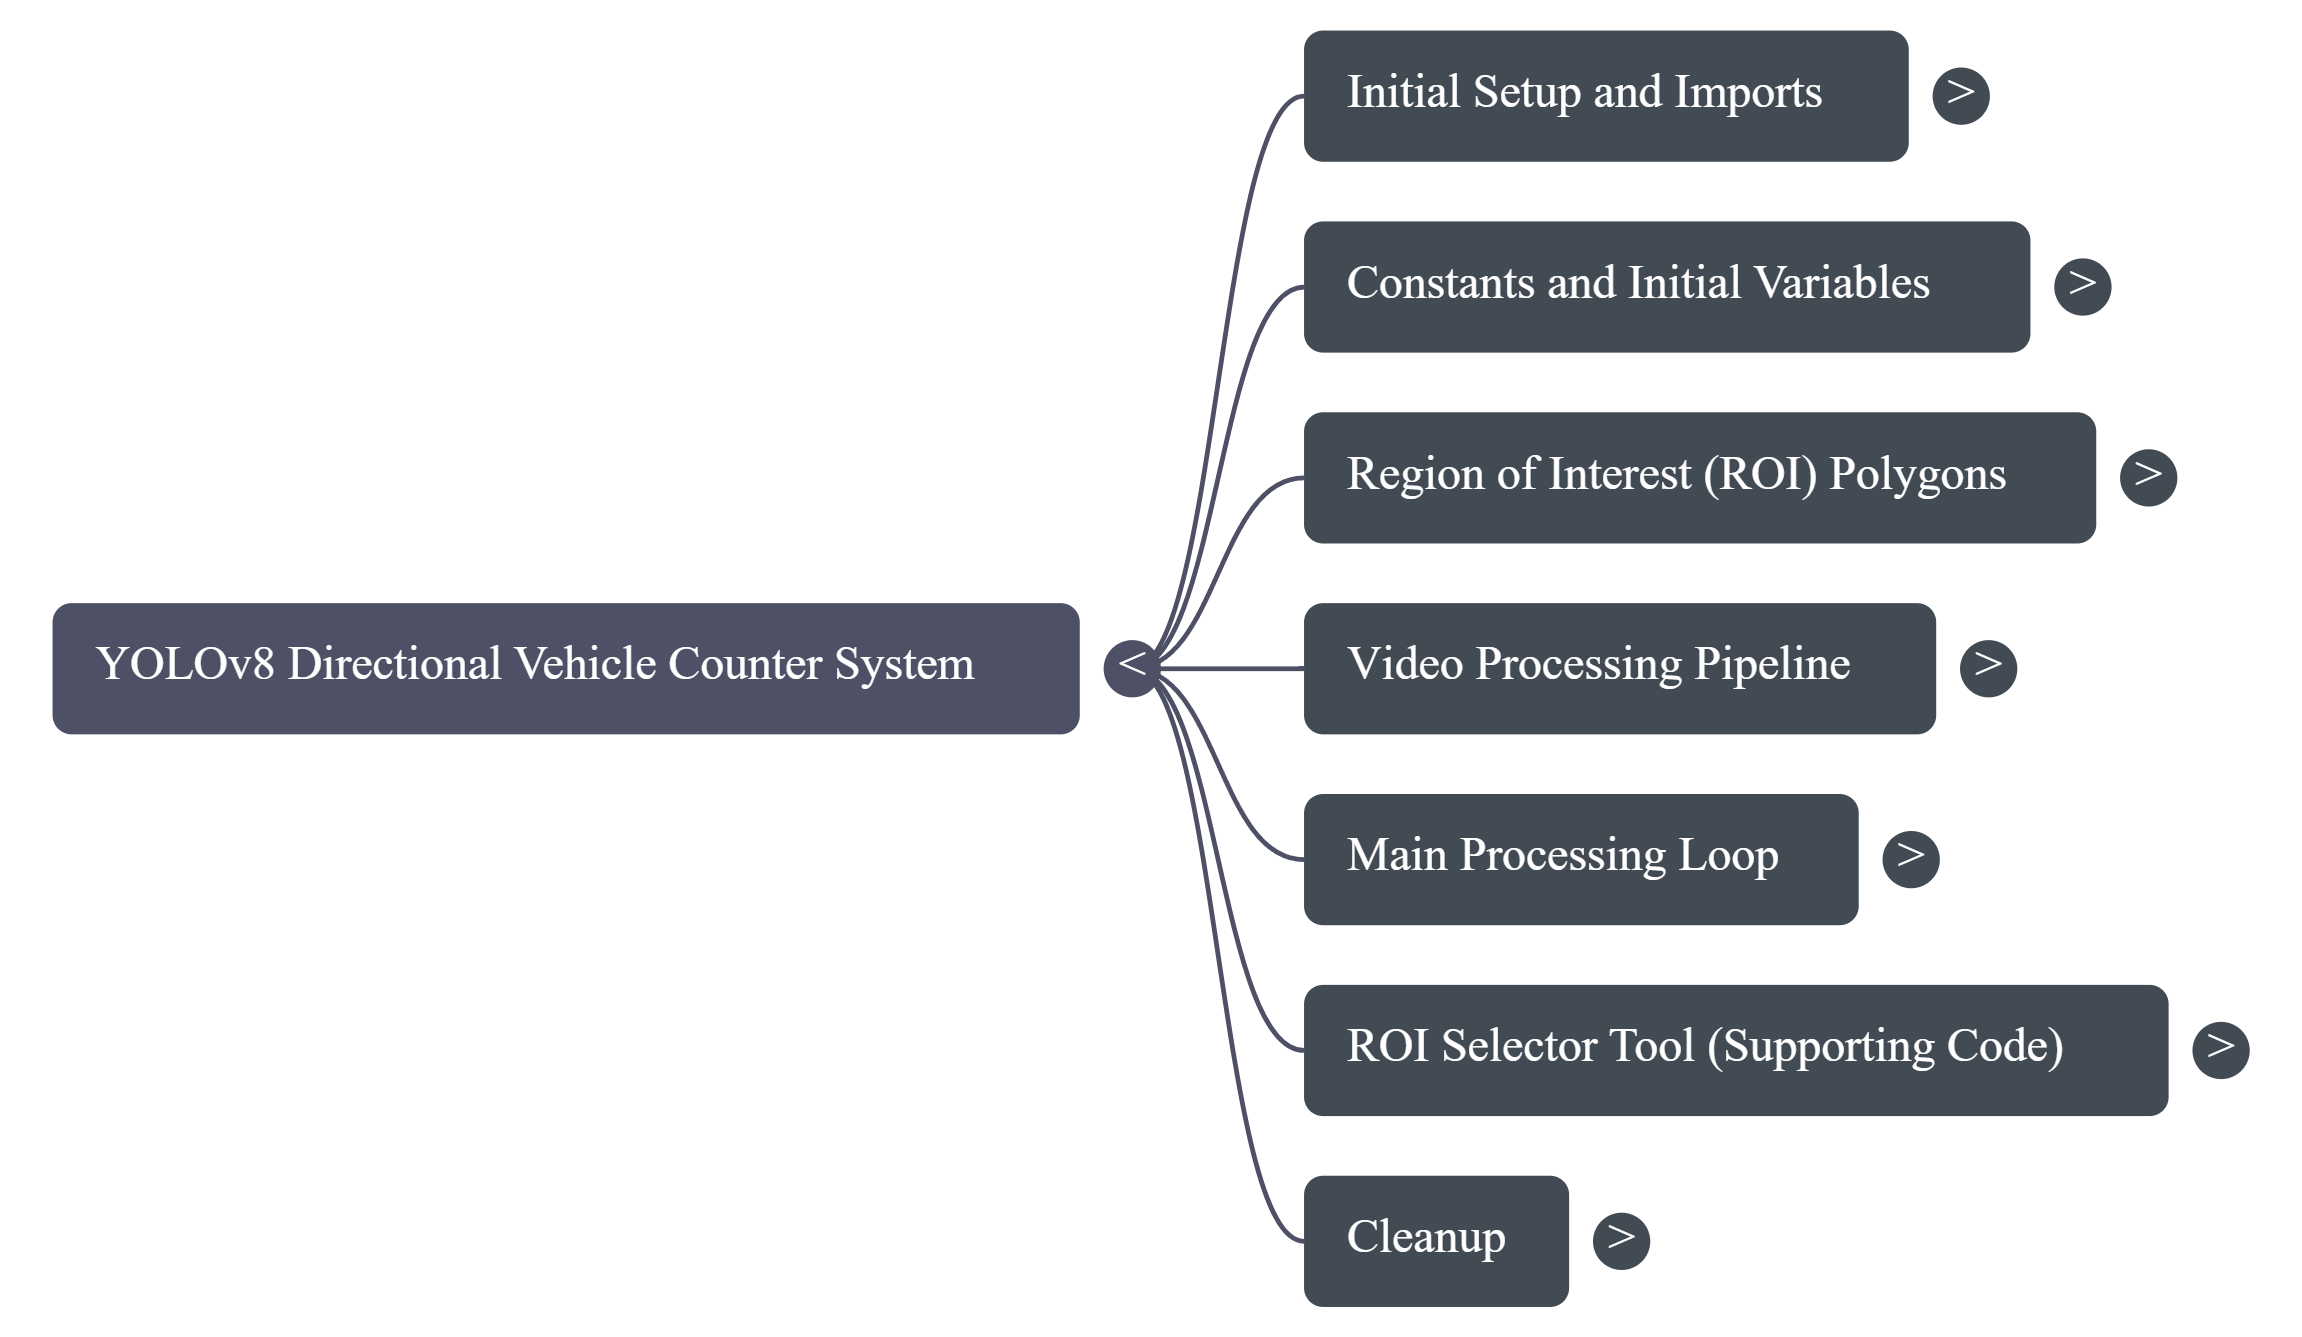

## 1. Importing the Required Libraries and Environment Settings


In [4]:
import os

# [EXPERT NOTE] This setting is used to prevent possible library conflicts,
# such as the "OMP: Error #15" error.

# It is a safety precaution to help the code run properly.

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [6]:
import cv2  # OpenCV for image processing

import imutils  # Helper tools for OpenCV, such as resizing

import numpy as np  # Used for numerical operations and array management

from ultralytics import YOLO  # Used to load and run the YOLO model

# `defaultdict` allows a dictionary to automatically create
# a default value, such as an empty list, when a key does not exist.

from collections import defaultdict

## 2. Visualization Constants: Colors and Fonts


In [8]:
# We define the colors that will be used in the drawings in BGR format,
# which stands for Blue, Green, Red and is the color format used by OpenCV.

blue = (255, 0, 0)
green = (0, 255, 0)
red = (0, 0, 255)
black = (0, 0, 0)
white = (255, 255, 255)  # Used for the white panel/window in the top-left corner of the screen

thickness = 2  # Thickness of the lines, such as polygons and bounding boxes
font_scale = 0.6  # Text size
font = cv2.FONT_HERSHEY_SIMPLEX  # Font type to be used

## 3. Direction Counting Dictionaries


In [12]:
# [MAIN LOGIC] These dictionaries will be used to store the unique IDs
# of the vehicles that enter each region.

# By using a vehicle's ID as the dictionary key,
# we prevent the same vehicle from increasing the counter again and again
# every time it passes through the same region.

up = {}        # For vehicles going upward
down = {}      # For vehicles going downward
left = {}      # For vehicles turning left
right = {}     # For vehicles turning right

In [14]:
# We will only consider the vehicle classes in the COCO dataset:
# car, motorcycle, bus, and truck.

vehicles = [2, 3, 5, 7]  # We can also find these index numbers with a Google search

## 4. Defining the Region of Interest (ROI) Polygons


In [17]:
# We manually define 4 polygons, or regions, for the four entrances/exits of the intersection.

# If the center point of a vehicle enters one of these polygons,
# we assume that the vehicle is moving in that direction.

# The coordinates must match the frame size set by `imutils.resize(frame, width=1280)`.

# Polygon for vehicles going upward
# We wrote the polygon points here using the coordinates obtained
# from the other ROI_selection notebook.
polygon_up = np.array([[467, 295], [578, 370],
                       [710, 361], [559, 283]], np.int32)

# Polygon for vehicles going downward
polygon_down = np.array([[760, 610], [490, 660],
                         [527, 714], [890, 711]], np.int32)

# Polygon for vehicles turning left
polygon_left = np.array([[107, 451], [213, 438],
                         [220, 469], [85, 481]], np.int32)
# As an additional improvement, this area can be adjusted in a different way.

# Polygon for vehicles turning right
polygon_right = np.array([[990, 453], [1262, 404],
                          [1276, 467], [1072, 506]], np.int32)

## 5. Video Input, Model Loading, and Tracking History


In [20]:
video_path = "inference/intersection.mp4"

cap = cv2.VideoCapture(video_path)  # Open the video file
model = YOLO("models/yolo11s.pt")  # Load the YOLOv11s small model

# `track_history` will store a list of coordinates for each `track_id`.
# This allows us to draw the movement trail of the vehicles.

# Thanks to `defaultdict(lambda: [])`, when a new ID appears,
# an empty list is automatically created for it.

track_history = defaultdict(lambda: [])

## 6. Video Output / Writing Settings


In [23]:
width = 1280
height = 720

# Output video resolution.
# It should be the same as the 1280x720 value
# used when resizing the input frame.

fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec used for saving the video

# Create a video writer object named "video_output.avi",
# with 20 frames per second (20.0 FPS)
# and a resolution of (width, height).

writer = cv2.VideoWriter("video_output.avi", fourcc, 20.0, (width, height))

## 7. Main Processing Loop


In [26]:
while True:
    # Read one frame from the video
    ret, frame = cap.read()
    if ret == False:
        break  # If the video has ended, exit the loop

    # Resize the frame to a standard size, with a width of 1280.
    # This ensures that our polygon coordinates always remain consistent.
    frame = imutils.resize(frame, width=1280)

    
    # --- 8. Drawing the Polygons ---
    
    # We draw the 4 regions, or ROIs, that we defined on the frame in green.
    # This connects the coordinate points and forms the polygon areas.
    # We entered these polygon points above.
    
    cv2.polylines(frame, [polygon_up], isClosed=True, color=green, thickness=thickness)
    # `isClosed=True` means the polygon is drawn as a closed shape.
    
    cv2.polylines(frame, [polygon_down], isClosed=True, color=green, thickness=thickness)
    cv2.polylines(frame, [polygon_left], isClosed=True, color=green, thickness=thickness)
    cv2.polylines(frame, [polygon_right], isClosed=True, color=green, thickness=thickness)

    
    # --- 9. Object Detection and Tracking with YOLOv11 ---
    
    # `persist=True`: Allows the model to remember and track objects between frames.
    # `verbose=False`: Prevents detailed logs from being printed to the console.
    results = model.track(frame, persist=True, verbose=False)[0]
    
    # Convert the detected boxes, or bounding boxes, into a NumPy array as integers.
    bboxes = np.array(results.boxes.data.tolist(), dtype="int")

    
    # --- 10. Processing the Detected Vehicles ---
    # Start a loop for each detected `box`.
   
    for box in bboxes:
        # Get the box information:
        # [x1, y1, x2, y2, track_id, score, class_id]
        x1, y1, x2, y2, track_id, score, class_id = box
        
        # Calculate the center point, or centroid, of the vehicle.
        # We identify vehicles based on their center point.
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        
        # If the detected object is a vehicle, meaning it is in the `vehicles` list:
        
        if class_id in vehicles:
            # --- 10a. Visualization: Box, Center Point, and ID ---
            
            # Draw a blue circle at the center of the vehicle
            cv2.circle(frame, (cx, cy), 3, blue, -1)
            
            # Draw a blue detection box around the vehicle
            cv2.rectangle(frame, (x1, y1), (x2, y2), blue, thickness=1)

            # Get the class name, for example "CAR", and combine it with the ID
            class_name = results.names[class_id].upper()
            text = "ID:{} {}".format(track_id, class_name)
            
            # Write the text just above the bounding box
            cv2.putText(frame, text, (x1, y1 - 5), font, font_scale, blue, thickness)

            # --- 10b. Drawing the Vehicle Trail ---
            
            # Get the previous coordinate list of this vehicle using its `track_id`
            track = track_history[track_id]
            
            # Add the center point from this frame, (cx, cy), to the list
            track.append((cx, cy))

            # If the trail length exceeds 15 coordinates,
            # remove the oldest coordinate from the list using `pop(0)`.
            # This prevents the screen from being filled with too many lines.
            
            if len(track) > 15:
                track.pop(0)

            # Convert the `track` list into the format required by `cv2.polylines`
            points = np.hstack(track).astype(np.int32).reshape((-1, 1, 2))
            
            # Draw the vehicle trail on the frame as a blue line
            cv2.polylines(frame, [points], isClosed=False, color=blue, thickness=thickness)

            # --- 10c. Direction Detection: Point-in-Polygon Test ---
            
            # Use `cv2.pointPolygonTest` to check which polygon contains
            # the vehicle's center point, (cx, cy).
            # If the result is > 0, the point is INSIDE the polygon.
            
            up_result = cv2.pointPolygonTest(polygon_up, (cx, cy), measureDist=False)
            down_result = cv2.pointPolygonTest(polygon_down, (cx, cy), measureDist=False)
            left_result = cv2.pointPolygonTest(polygon_left, (cx, cy), measureDist=False)
            right_result = cv2.pointPolygonTest(polygon_right, (cx, cy), measureDist=False)

            # If the vehicle is inside the "up" polygon:
            if up_result > 0:
                # print("UP!")
                # Add this vehicle's `track_id` to the `up` dictionary.
                # If it already exists, only the value is updated,
                # so the count does not increase again.
                up[track_id] = x1, y1, x2, y2

            # If the vehicle is inside the "down" polygon:
            if down_result > 0:
                # print("DOWN!")
                down[track_id] = x1, y1, x2, y2

            # If the vehicle is inside the "left" polygon:
            if left_result > 0:
                # print("LEFT!")
                left[track_id] = x1, y1, x2, y2

            # If the vehicle is inside the "right" polygon:
            if right_result > 0:
                # print("RIGHT!")
                right[track_id] = x1, y1, x2, y2

    
    # --- 11. Displaying the Counting Results on the Screen ---
    
    # By getting the number of keys in each dictionary,
    # for example `len(list(up.keys()))`,
    # we find the number of unique vehicles that entered each region.
    
    up_counter_text = "Up Direction Counter: {}".format(str(len(list(up.keys()))))
    down_counter_text = "Down Direction Counter: {}".format(str(len(list(down.keys()))))
    left_counter_text = "Left Direction Counter: {}".format(str(len(list(left.keys()))))
    right_counter_text = "Right Direction Counter: {}".format(str(len(list(right.keys()))))

    
    # Draw a white background rectangle in the top-left corner,
    # from (0, 0) to (350, 150).
    # We will write the vehicle counts on top of this background.
    cv2.rectangle(frame, (0, 0), (350, 150), white, -1)
    # Top-left corner: (0, 0)
    # Bottom-right corner: (350, 150)
    # Color: white
    # -1 means the rectangle is filled.
    
    # Write the counting texts on this white background.
    cv2.putText(frame, up_counter_text, (10, 25), font, 0.8, black, thickness)
    cv2.putText(frame, down_counter_text, (10, 65), font, 0.8, black, thickness)
    cv2.putText(frame, left_counter_text, (10, 105), font, 0.8, black, thickness)
    cv2.putText(frame, right_counter_text, (10, 145), font, 0.8, black, thickness)

    
    # --- 12. Saving and Displaying ---
    
    # Write the processed frame, which includes the drawings, to the video file.
    writer.write(frame)
   
    # Display the processed frame in a window named "Direction Counter".
    cv2.imshow("Direction Counter", frame)
    
    # If the `q` key is pressed, exit the loop.
    if cv2.waitKey(10) & 0xFF == ord("q"):
        break

When you run the code above, a new window will open.

The count for each direction will be displayed in a panel at the top-left corner of the screen.


## 13. Cleanup 

In [28]:
# Release the video reader
cap.release()

# Release the video writer.
# This is required to make sure the file is saved properly.
writer.release()

# Close all OpenCV windows
cv2.destroyAllWindows()

# Print an information message to the console indicating that the process is finished
print("[INFO]... Processing is finished, video_output is recorded!")

[INFO]...Processing is finished, video_output is recorded!
